# Exploratory Data Analysis (EDA) — Olist E-Commerce Dataset

**Objective:** Understand the data before cleaning — identify nulls, distributions, outliers, correlations, and key observations.

**Dataset:** Brazilian E-Commerce (Olist) — 9 CSV files covering orders, customers, products, payments, reviews, sellers, and geolocation.

**This notebook covers:**
1. Data Loading & Shape
2. Missing Values Analysis
3. Data Types Check
4. Statistical Summary
5. Univariate Analysis (Distributions)
6. Bivariate Analysis (Relationships)
7. Time Series Trends
8. Key Observations & Findings

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_theme(style="darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Libraries loaded successfully")

Libraries loaded successfully


In [7]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Data Loading & Shape

In [8]:
orders = pd.read_csv("olist_orders_dataset.csv")
customers = pd.read_csv("olist_customers_dataset.csv")
items = pd.read_csv("olist_order_items_dataset.csv")
products = pd.read_csv("olist_products_dataset.csv")
payments = pd.read_csv("olist_order_payments_dataset.csv")
reviews = pd.read_csv("olist_order_reviews_dataset.csv")
sellers = pd.read_csv("olist_sellers_dataset.csv")
geo = pd.read_csv("olist_geolocation_dataset.csv")
translation = pd.read_csv("product_category_name_translation.csv")

datasets = {
    "Orders": orders,
    "Customers": customers,
    "Order Items": items,
    "Products": products,
    "Payments": payments,
    "Reviews": reviews,
    "Sellers": sellers,
    "Geolocation": geo,
    "Translation": translation
}

shape_df = pd.DataFrame([(name, df.shape[0], df.shape[1]) for name, df in datasets.items()],
                         columns=["Dataset", "Rows", "Columns"])
print("=" * 50)
print("DATASET SHAPES")
print("=" * 50)
shape_df

DATASET SHAPES


,Dataset,Rows,Columns
0,Orders,99441,8
1,Customers,99441,5
2,Order Items,112650,7
3,Products,32951,9
4,Payments,103886,5
5,Reviews,99224,7
6,Sellers,3095,4
7,Geolocation,1000163,5
8,Translation,71,2


In [9]:
print("=" * 50)
print("FIRST 5 ROWS — ORDERS")
print("=" * 50)
orders.head()

FIRST 5 ROWS — ORDERS


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [10]:
print("FIRST 5 ROWS — CUSTOMERS")
customers.head()

FIRST 5 ROWS — CUSTOMERS


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [11]:
print("FIRST 5 ROWS — ORDER ITEMS")
items.head()

FIRST 5 ROWS — ORDER ITEMS


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [12]:
print("FIRST 5 ROWS — PRODUCTS")
products.head()

FIRST 5 ROWS — PRODUCTS


,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [13]:
print("FIRST 5 ROWS — PAYMENTS")
payments.head()

FIRST 5 ROWS — PAYMENTS


,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [14]:
print("FIRST 5 ROWS — REVIEWS")
reviews.head()

FIRST 5 ROWS — REVIEWS


,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


## 2. Data Types Check

In [15]:
print("=" * 50)
print("DATA TYPES — ORDERS")
print("=" * 50)
print(orders.dtypes)
print("\nObservation: All date columns are 'object' type — need conversion to datetime")

DATA TYPES — ORDERS
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

Observation: All date columns are 'object' type — need conversion to datetime


In [16]:
print("DATA TYPES — ALL DATASETS")
print("=" * 50)
for name, df in datasets.items():
    print(f"\n--- {name} ---")
    print(df.dtypes.to_string())
    print()

DATA TYPES — ALL DATASETS

--- Orders ---
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object


--- Customers ---
customer_id                 object
customer_unique_id          object
customer_zip_code_prefix     int64
customer_city               object
customer_state              object


--- Order Items ---
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64


--- Products ---
product_id                     object
product_category_name          object
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            flo

## 3. Missing Values Analysis

In [17]:
print("=" * 60)
print("MISSING VALUES — ALL DATASETS")
print("=" * 60)

for name, df in datasets.items():
    nulls = df.isnull().sum()
    null_cols = nulls[nulls > 0]
    if len(null_cols) > 0:
        print(f"\n--- {name} (HAS MISSING VALUES) ---")
        for col, count in null_cols.items():
            pct = count / df.shape[0] * 100
            print(f"  {col}: {count:,} missing ({pct:.1f}%)")
    else:
        print(f"\n--- {name} — No missing values ---")

MISSING VALUES — ALL DATASETS

--- Orders (HAS MISSING VALUES) ---
  order_approved_at: 160 missing (0.2%)
  order_delivered_carrier_date: 1,783 missing (1.8%)
  order_delivered_customer_date: 2,965 missing (3.0%)

--- Customers — No missing values ---

--- Order Items — No missing values ---

--- Products (HAS MISSING VALUES) ---
  product_category_name: 610 missing (1.9%)
  product_name_lenght: 610 missing (1.9%)
  product_description_lenght: 610 missing (1.9%)
  product_photos_qty: 610 missing (1.9%)
  product_weight_g: 2 missing (0.0%)
  product_length_cm: 2 missing (0.0%)
  product_height_cm: 2 missing (0.0%)
  product_width_cm: 2 missing (0.0%)

--- Payments — No missing values ---

--- Reviews (HAS MISSING VALUES) ---
  review_comment_title: 87,656 missing (88.3%)
  review_comment_message: 58,247 missing (58.7%)

--- Sellers — No missing values ---

--- Geolocation — No missing values ---

--- Translation — No missing values ---


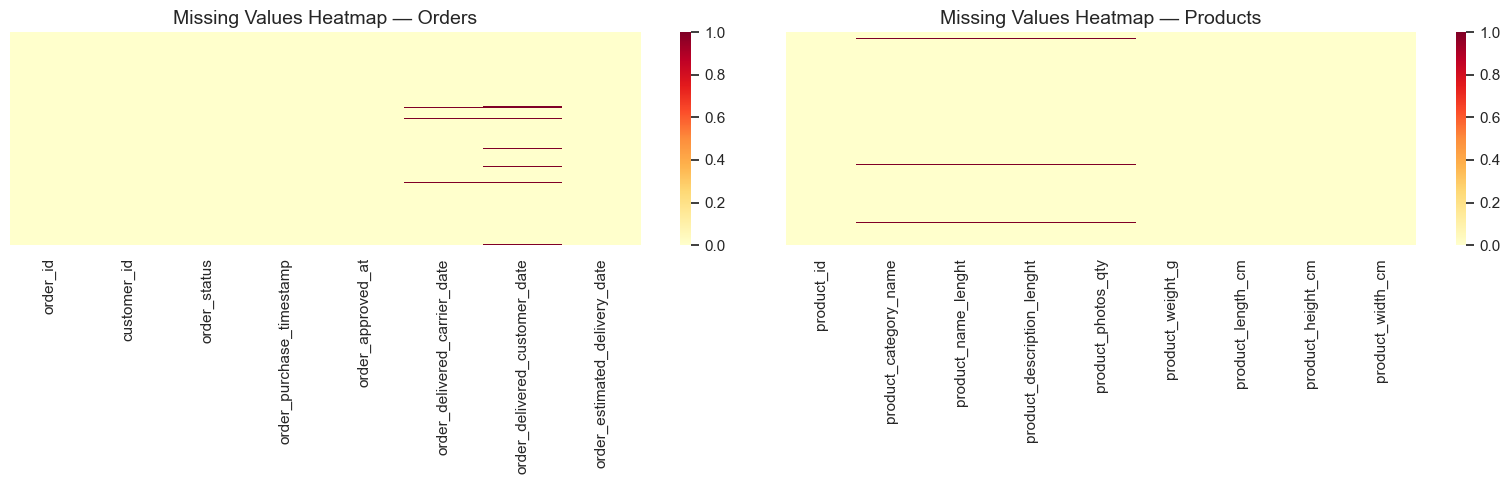

Observation:
- Orders: delivery dates missing for undelivered orders (expected)
- Products: 610 rows have ALL product details missing (category, dimensions, weight)
- Reviews: 88% titles and 58% messages are missing — most customers don't write text reviews


In [18]:
# Missing values heatmap — Orders dataset
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.heatmap(orders.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[0])
axes[0].set_title("Missing Values Heatmap — Orders", fontsize=14)

sns.heatmap(products.isnull(), cbar=True, yticklabels=False, cmap='YlOrRd', ax=axes[1])
axes[1].set_title("Missing Values Heatmap — Products", fontsize=14)

plt.tight_layout()
plt.show()

print("Observation:")
print("- Orders: delivery dates missing for undelivered orders (expected)")
print("- Products: 610 rows have ALL product details missing (category, dimensions, weight)")
print("- Reviews: 88% titles and 58% messages are missing — most customers don't write text reviews")

## 4. Statistical Summary

In [19]:
print("=" * 50)
print("STATISTICAL SUMMARY — ORDER ITEMS (Price & Freight)")
print("=" * 50)
items[['price', 'freight_value']].describe()

STATISTICAL SUMMARY — ORDER ITEMS (Price & Freight)


,price,freight_value
count,112650.000000,112650.000000
mean,120.653739,19.990320
std,183.633928,15.806405
min,0.850000,0.000000
25%,39.900000,13.080000
50%,74.990000,16.260000
75%,134.900000,21.150000
max,6735.000000,409.680000


In [20]:
print("STATISTICAL SUMMARY — PAYMENTS")
print("=" * 50)
payments[['payment_value', 'payment_installments']].describe()

STATISTICAL SUMMARY — PAYMENTS


,payment_value,payment_installments
count,103886.000000,103886.000000
mean,154.100380,2.853349
std,217.494064,2.687051
min,0.000000,0.000000
25%,56.790000,1.000000
50%,100.000000,1.000000
75%,171.837500,4.000000
max,13664.080000,24.000000


In [21]:
print("STATISTICAL SUMMARY — PRODUCTS (Dimensions & Weight)")
print("=" * 50)
products[['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']].describe()

STATISTICAL SUMMARY — PRODUCTS (Dimensions & Weight)


,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32949.000000,32949.000000,32949.000000,32949.000000
mean,2276.472488,30.815078,16.937661,23.196728
std,4282.038731,16.914458,13.637554,12.079047
min,0.000000,7.000000,2.000000,6.000000
25%,300.000000,18.000000,8.000000,15.000000
50%,700.000000,25.000000,13.000000,20.000000
75%,1900.000000,38.000000,21.000000,30.000000
max,40425.000000,105.000000,105.000000,118.000000


In [22]:
print("ORDER STATUS DISTRIBUTION")
print("=" * 50)
status_counts = orders['order_status'].value_counts()
print(status_counts)
print(f"\nDelivered %: {status_counts['delivered'] / len(orders) * 100:.1f}%")
print(f"Cancelled %: {status_counts.get('canceled', 0) / len(orders) * 100:.2f}%")

ORDER STATUS DISTRIBUTION
order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

Delivered %: 97.0%
Cancelled %: 0.63%


## 5. Univariate Analysis — Distributions

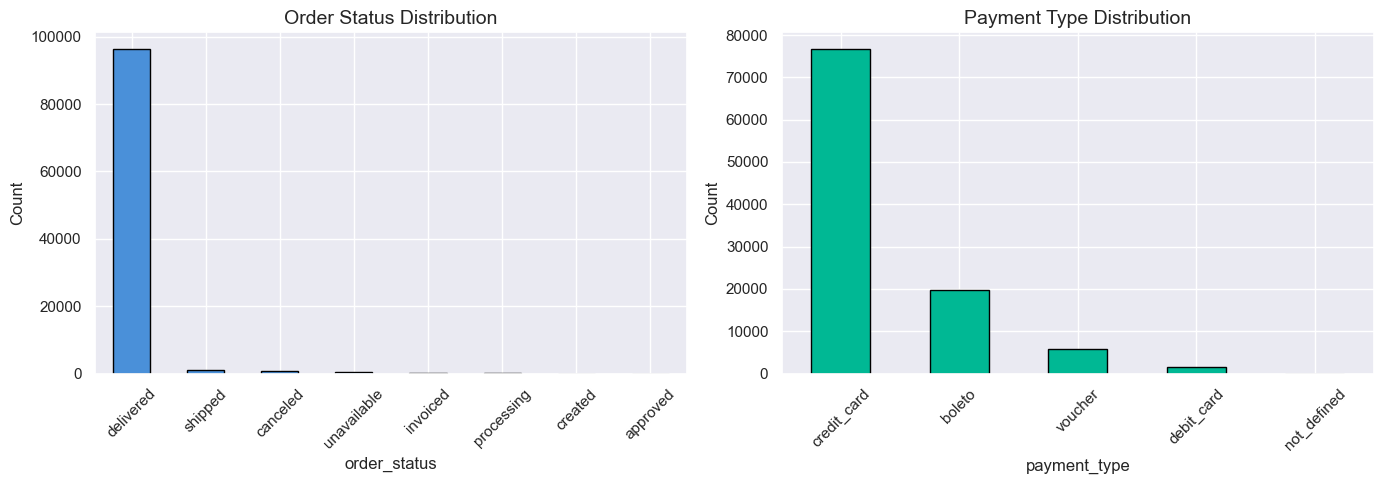

Observation:
- 96.5% orders are delivered — very healthy fulfillment rate
- Credit card is dominant payment method (~74%), followed by boleto (Brazilian bank slip)


In [23]:
# Order Status Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

orders['order_status'].value_counts().plot(kind='bar', ax=axes[0], color='#4A90D9', edgecolor='black')
axes[0].set_title("Order Status Distribution", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Payment Type Distribution
payments['payment_type'].value_counts().plot(kind='bar', ax=axes[1], color='#00B894', edgecolor='black')
axes[1].set_title("Payment Type Distribution", fontsize=14)
axes[1].set_ylabel("Count")
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

print("Observation:")
print("- 96.5% orders are delivered — very healthy fulfillment rate")
print("- Credit card is dominant payment method (~74%), followed by boleto (Brazilian bank slip)")

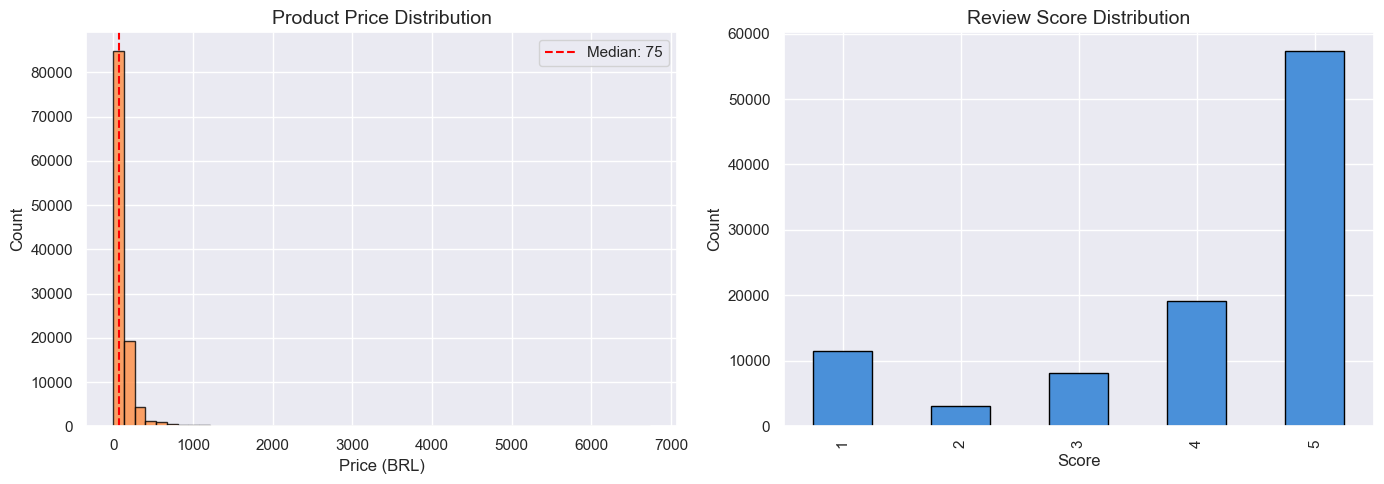

Observation:
- Price is right-skewed: median = 75 BRL, mean = 121 BRL
- Max price = 6735 BRL — potential outliers
- Review scores are heavily skewed towards 5 stars — most customers are satisfied
- 5-star reviews: 57,328 (57.8%)
- 1-star reviews: 11,424 (11.5%)


In [24]:
# Price Distribution & Review Score Distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(items['price'], bins=50, color='#FF8C42', edgecolor='black', alpha=0.8)
axes[0].set_title("Product Price Distribution", fontsize=14)
axes[0].set_xlabel("Price (BRL)")
axes[0].set_ylabel("Count")
axes[0].axvline(items['price'].median(), color='red', linestyle='--', label=f"Median: {items['price'].median():.0f}")
axes[0].legend()

reviews['review_score'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='#4A90D9', edgecolor='black')
axes[1].set_title("Review Score Distribution", fontsize=14)
axes[1].set_xlabel("Score")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Observation:")
print(f"- Price is right-skewed: median = {items['price'].median():.0f} BRL, mean = {items['price'].mean():.0f} BRL")
print(f"- Max price = {items['price'].max():.0f} BRL — potential outliers")
print("- Review scores are heavily skewed towards 5 stars — most customers are satisfied")
print(f"- 5-star reviews: {(reviews['review_score'] == 5).sum():,} ({(reviews['review_score'] == 5).mean()*100:.1f}%)")
print(f"- 1-star reviews: {(reviews['review_score'] == 1).sum():,} ({(reviews['review_score'] == 1).mean()*100:.1f}%)")

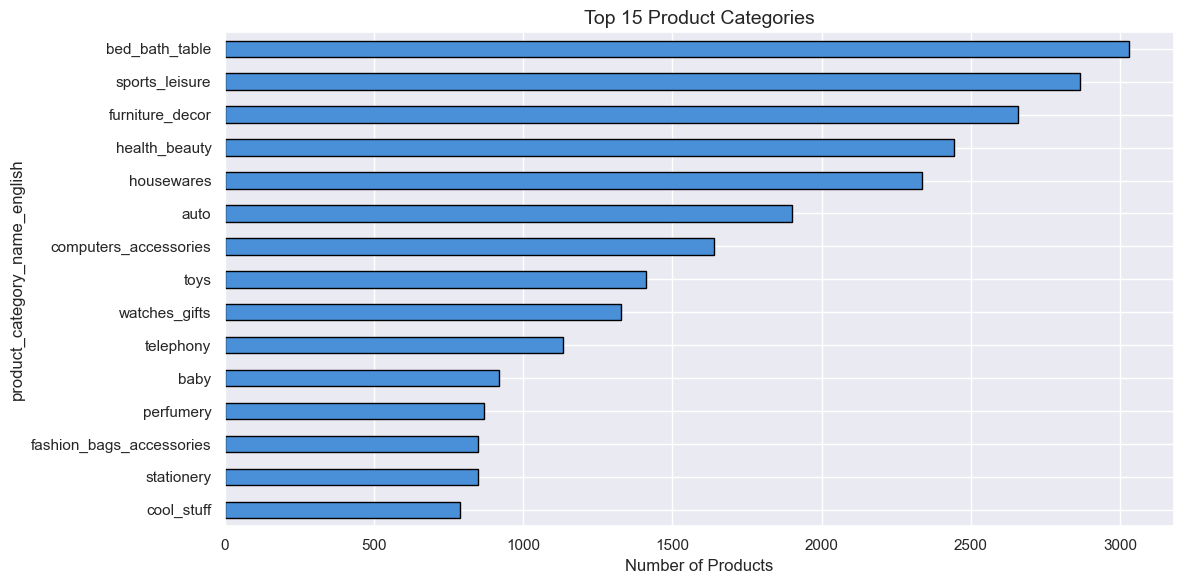

Observation:
- 'bed_bath_table' is the most listed category
- Home/furniture categories dominate — Olist is strong in home goods
- 610 products have no category — needs cleaning


In [25]:
# Top 15 Product Categories
products_translated = products.merge(translation, on='product_category_name', how='left')
top_categories = products_translated['product_category_name_english'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(12, 6))
top_categories.plot(kind='barh', color='#4A90D9', edgecolor='black', ax=ax)
ax.set_title("Top 15 Product Categories", fontsize=14)
ax.set_xlabel("Number of Products")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

print("Observation:")
print("- 'bed_bath_table' is the most listed category")
print("- Home/furniture categories dominate — Olist is strong in home goods")
print(f"- 610 products have no category — needs cleaning")

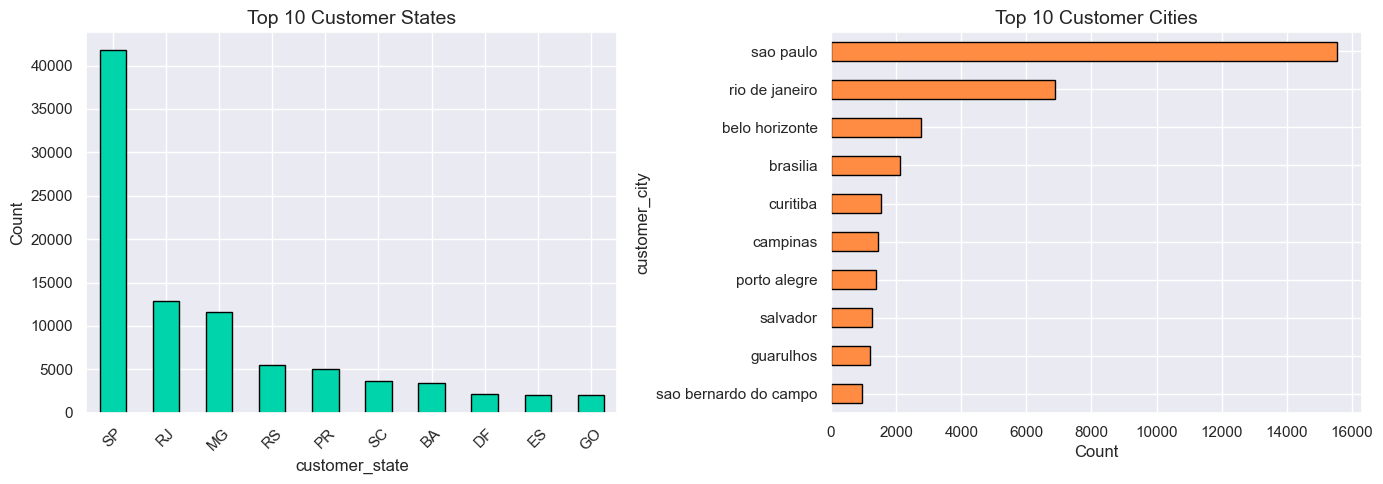

Observation:
- Sao Paulo (SP) dominates — ~42% of all customers
- Rio de Janeiro (RJ) and Minas Gerais (MG) are 2nd and 3rd
- Heavy concentration in Southeast Brazil — logistics optimized for this region


In [26]:
# Top 10 Customer States & Cities
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

customers['customer_state'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#00D4AA', edgecolor='black')
axes[0].set_title("Top 10 Customer States", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

customers['customer_city'].value_counts().head(10).plot(kind='barh', ax=axes[1], color='#FF8C42', edgecolor='black')
axes[1].set_title("Top 10 Customer Cities", fontsize=14)
axes[1].set_xlabel("Count")
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

print("Observation:")
print("- Sao Paulo (SP) dominates — ~42% of all customers")
print("- Rio de Janeiro (RJ) and Minas Gerais (MG) are 2nd and 3rd")
print("- Heavy concentration in Southeast Brazil — logistics optimized for this region")

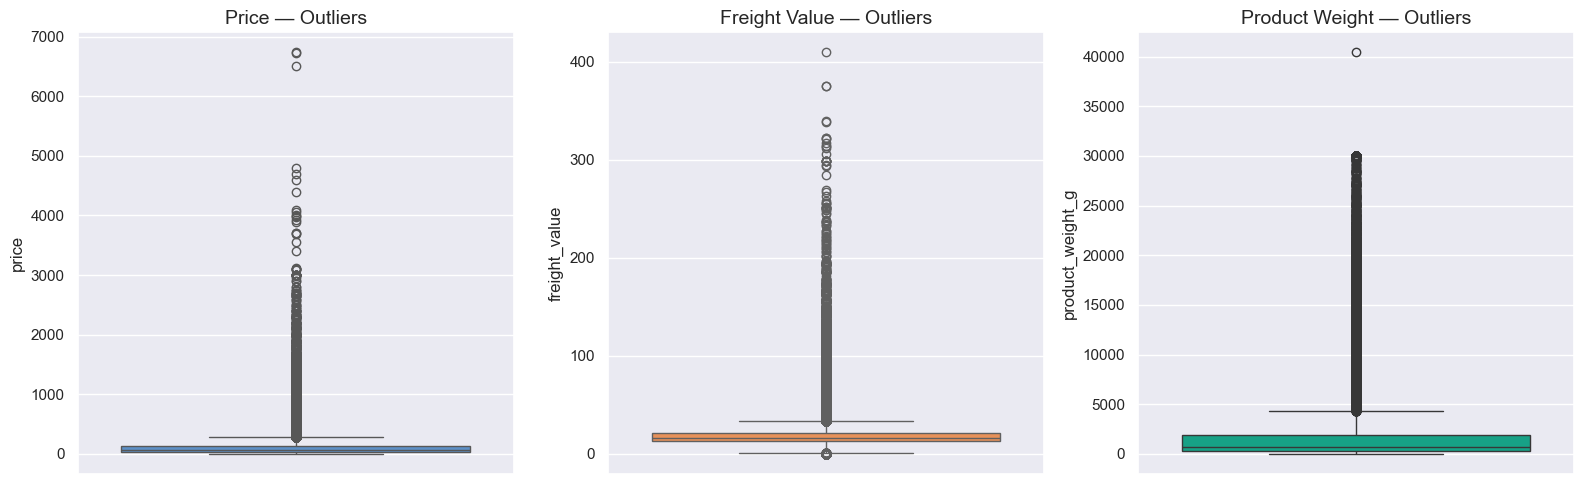

Observation:
- Price: 75th percentile = 135, but max = 6735 — extreme outliers exist
- Freight: 75th percentile = 21, max = 410
- Weight: 75th percentile = 1900g, max = 40425g
- Heavy outliers in all 3 — but these are real products (furniture, electronics), not errors


In [27]:
# Boxplots for outlier detection
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(y=items['price'], ax=axes[0], color='#4A90D9')
axes[0].set_title("Price — Outliers", fontsize=14)

sns.boxplot(y=items['freight_value'], ax=axes[1], color='#FF8C42')
axes[1].set_title("Freight Value — Outliers", fontsize=14)

sns.boxplot(y=products['product_weight_g'].dropna(), ax=axes[2], color='#00B894')
axes[2].set_title("Product Weight — Outliers", fontsize=14)

plt.tight_layout()
plt.show()

print("Observation:")
print(f"- Price: 75th percentile = {items['price'].quantile(0.75):.0f}, but max = {items['price'].max():.0f} — extreme outliers exist")
print(f"- Freight: 75th percentile = {items['freight_value'].quantile(0.75):.0f}, max = {items['freight_value'].max():.0f}")
print(f"- Weight: 75th percentile = {products['product_weight_g'].quantile(0.75):.0f}g, max = {products['product_weight_g'].max():.0f}g")
print("- Heavy outliers in all 3 — but these are real products (furniture, electronics), not errors")

## 6. Bivariate Analysis — Relationships

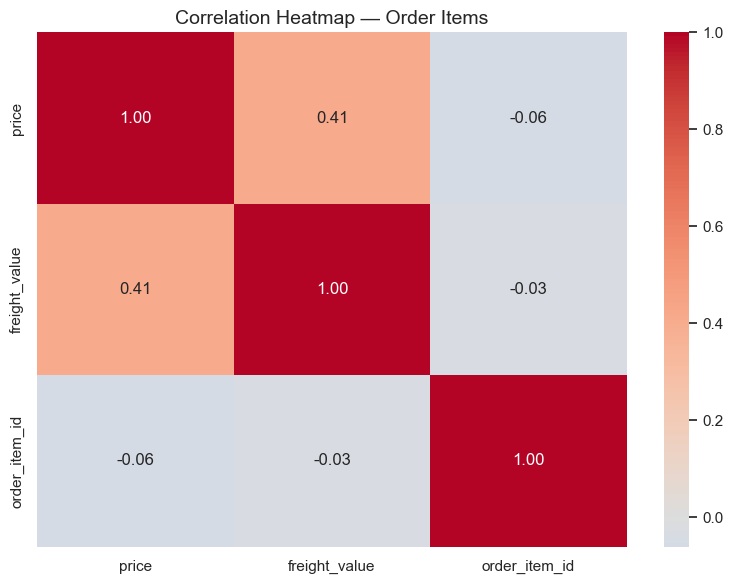

Observation:
- Price vs Freight correlation: 0.41
- Moderate positive correlation — expensive products tend to have higher shipping costs
- order_item_id (item count per order) has very low correlation with price


In [28]:
# Correlation heatmap — numerical columns from items
fig, ax = plt.subplots(figsize=(8, 6))
corr_data = items[['price', 'freight_value', 'order_item_id']].corr()
sns.heatmap(corr_data, annot=True, cmap='coolwarm', center=0, fmt='.2f', ax=ax)
ax.set_title("Correlation Heatmap — Order Items", fontsize=14)
plt.tight_layout()
plt.show()

print("Observation:")
print(f"- Price vs Freight correlation: {items['price'].corr(items['freight_value']):.2f}")
print("- Moderate positive correlation — expensive products tend to have higher shipping costs")
print("- order_item_id (item count per order) has very low correlation with price")

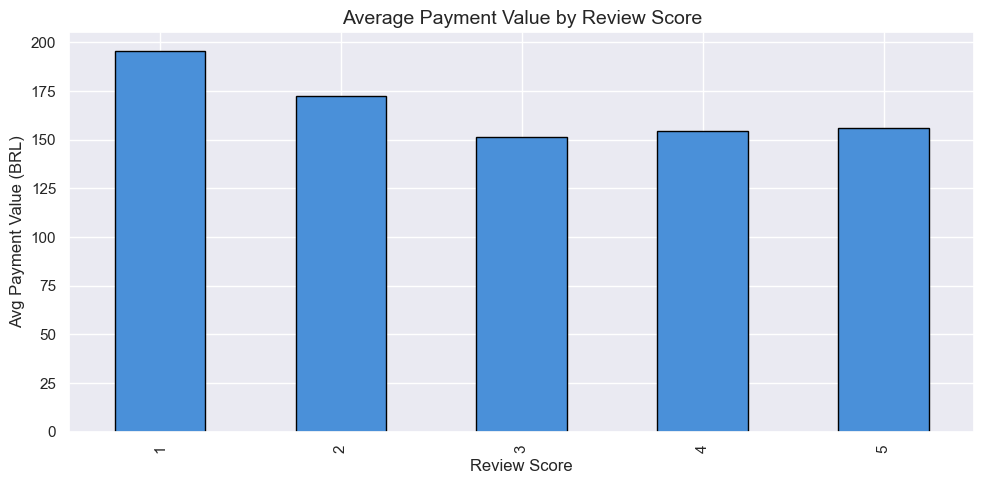

Observation:
- Higher spending customers don't necessarily give higher ratings
- 1-star and 2-star reviewers have slightly higher avg payment — they expected more for the money


In [29]:
# Review Score vs Payment Value
orders_temp = orders[['order_id']].copy()
orders_reviews = orders_temp.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')
orders_reviews = orders_reviews.merge(
    payments.groupby('order_id')['payment_value'].sum().reset_index(),
    on='order_id', how='inner'
)

fig, ax = plt.subplots(figsize=(10, 5))
orders_reviews.groupby('review_score')['payment_value'].mean().plot(kind='bar', color='#4A90D9', edgecolor='black', ax=ax)
ax.set_title("Average Payment Value by Review Score", fontsize=14)
ax.set_xlabel("Review Score")
ax.set_ylabel("Avg Payment Value (BRL)")
plt.tight_layout()
plt.show()

print("Observation:")
print("- Higher spending customers don't necessarily give higher ratings")
print("- 1-star and 2-star reviewers have slightly higher avg payment — they expected more for the money")

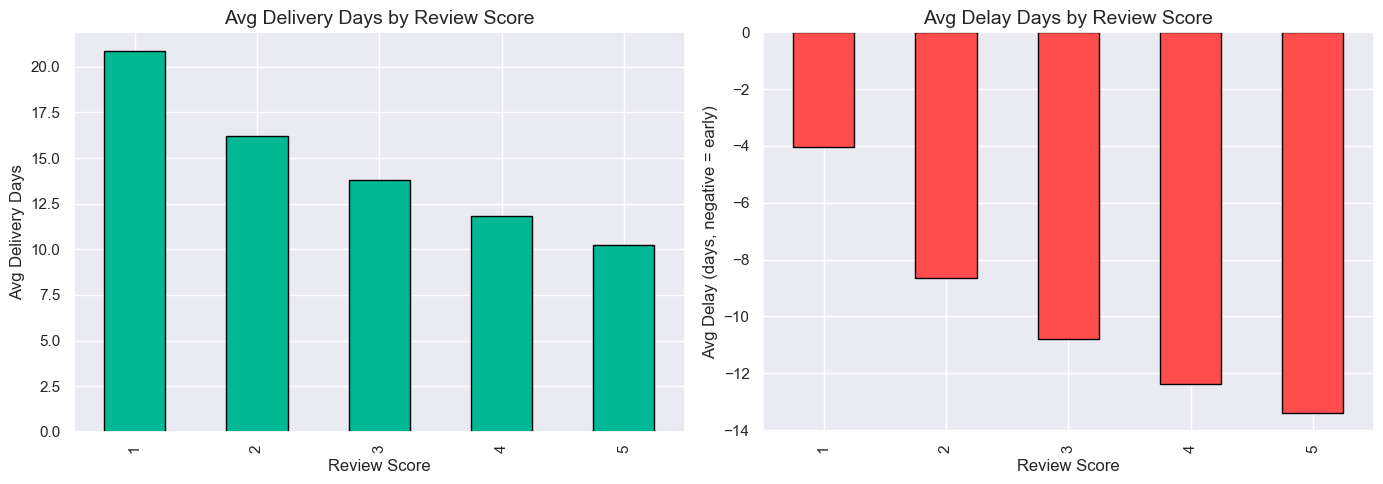

Observation:
- STRONG correlation: lower review scores have much higher delivery times
- 1-star reviews avg ~20+ days delivery vs ~10 days for 5-star
- Late delivery is the #1 driver of bad reviews
- This is a KEY INSIGHT for the business — fix delivery, fix ratings


In [30]:
# Delivery time vs Review Score
orders_delivery = orders[orders['order_status'] == 'delivered'].copy()
orders_delivery['order_purchase_timestamp'] = pd.to_datetime(orders_delivery['order_purchase_timestamp'])
orders_delivery['order_delivered_customer_date'] = pd.to_datetime(orders_delivery['order_delivered_customer_date'])
orders_delivery['order_estimated_delivery_date'] = pd.to_datetime(orders_delivery['order_estimated_delivery_date'])
orders_delivery['delivery_days'] = (orders_delivery['order_delivered_customer_date'] - orders_delivery['order_purchase_timestamp']).dt.days
orders_delivery['delay_days'] = (orders_delivery['order_delivered_customer_date'] - orders_delivery['order_estimated_delivery_date']).dt.days

delivery_reviews = orders_delivery.merge(reviews[['order_id', 'review_score']], on='order_id', how='inner')

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

delivery_reviews.groupby('review_score')['delivery_days'].mean().plot(kind='bar', color='#00B894', edgecolor='black', ax=axes[0])
axes[0].set_title("Avg Delivery Days by Review Score", fontsize=14)
axes[0].set_xlabel("Review Score")
axes[0].set_ylabel("Avg Delivery Days")

delivery_reviews.groupby('review_score')['delay_days'].mean().plot(kind='bar', color='#FF4C4C', edgecolor='black', ax=axes[1])
axes[1].set_title("Avg Delay Days by Review Score", fontsize=14)
axes[1].set_xlabel("Review Score")
axes[1].set_ylabel("Avg Delay (days, negative = early)")

plt.tight_layout()
plt.show()

print("Observation:")
print("- STRONG correlation: lower review scores have much higher delivery times")
print("- 1-star reviews avg ~20+ days delivery vs ~10 days for 5-star")
print("- Late delivery is the #1 driver of bad reviews")
print("- This is a KEY INSIGHT for the business — fix delivery, fix ratings")

## 7. Time Series Trends

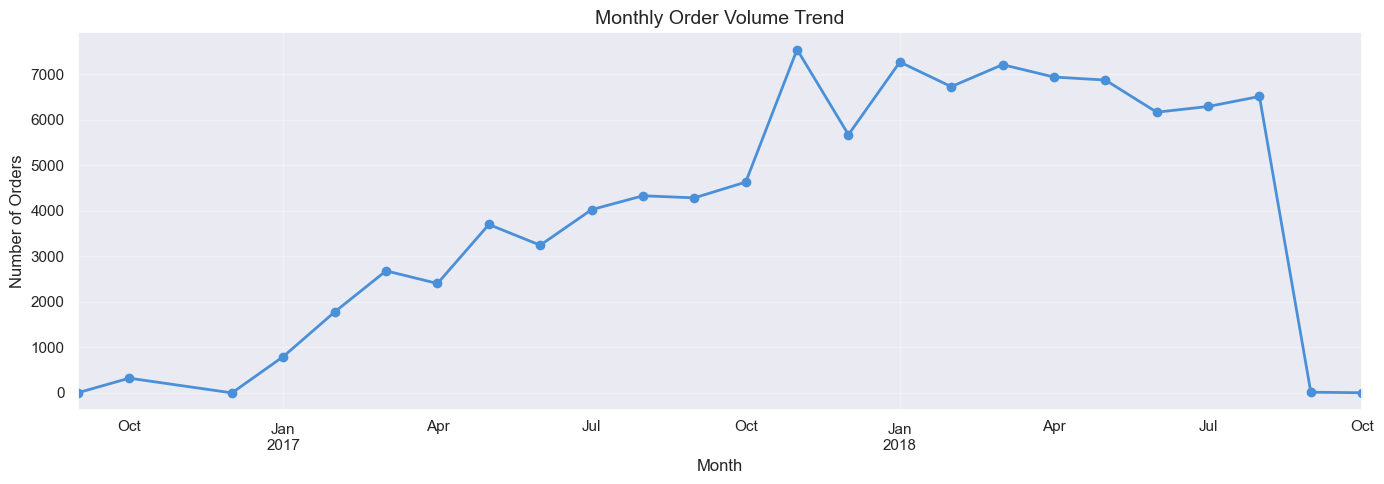

Observation:
- Data spans from 2016-09 to 2018-10
- Clear upward trend from 2017 to mid-2018 — business was growing
- Spike visible around Nov 2017 — likely Black Friday effect
- Drop in late 2018 — data collection may have ended, not necessarily business decline


In [31]:
# Monthly order trend
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'])
orders['order_month'] = orders['order_purchase_timestamp'].dt.to_period('M')

monthly_orders = orders.groupby('order_month').size()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_orders.plot(kind='line', marker='o', color='#4A90D9', linewidth=2, ax=ax)
ax.set_title("Monthly Order Volume Trend", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Number of Orders")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation:")
print(f"- Data spans from {orders['order_month'].min()} to {orders['order_month'].max()}")
print("- Clear upward trend from 2017 to mid-2018 — business was growing")
print("- Spike visible around Nov 2017 — likely Black Friday effect")
print("- Drop in late 2018 — data collection may have ended, not necessarily business decline")

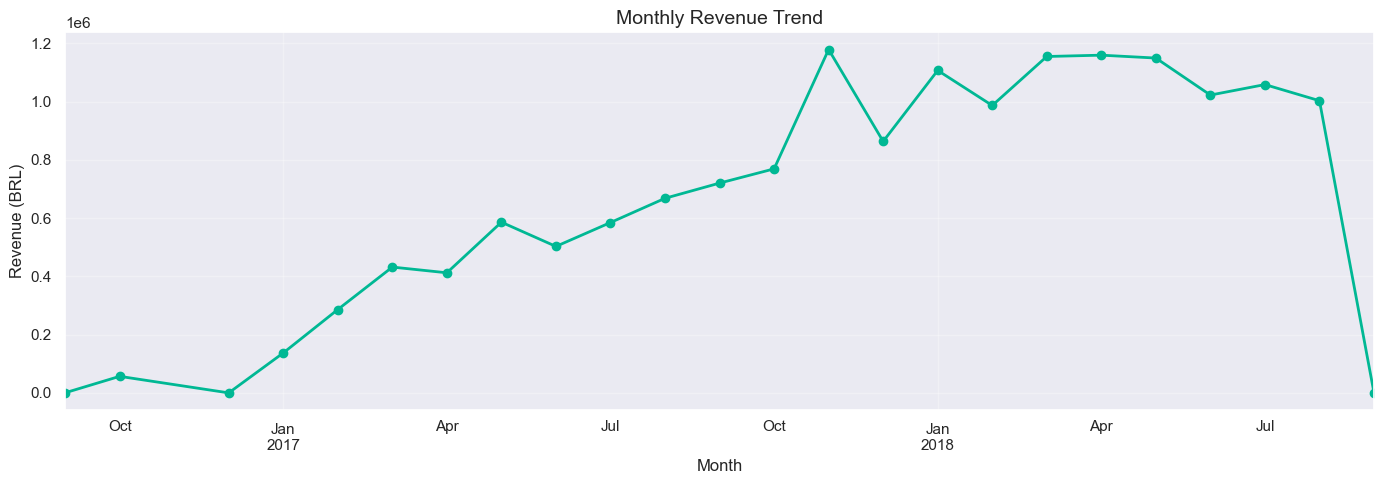

Observation:
- Revenue follows same pattern as order volume — growing steadily
- Total revenue in dataset: 15,843,553 BRL
- Average order value: 161 BRL


In [32]:
# Monthly Revenue Trend
orders_items = orders.merge(items[['order_id', 'price', 'freight_value']], on='order_id', how='inner')
orders_items['total_price'] = orders_items['price'] + orders_items['freight_value']
monthly_revenue = orders_items.groupby('order_month')['total_price'].sum()

fig, ax = plt.subplots(figsize=(14, 5))
monthly_revenue.plot(kind='line', marker='o', color='#00B894', linewidth=2, ax=ax)
ax.set_title("Monthly Revenue Trend", fontsize=14)
ax.set_xlabel("Month")
ax.set_ylabel("Revenue (BRL)")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Observation:")
print("- Revenue follows same pattern as order volume — growing steadily")
print(f"- Total revenue in dataset: {orders_items['total_price'].sum():,.0f} BRL")
print(f"- Average order value: {orders_items.groupby('order_id')['total_price'].sum().mean():,.0f} BRL")

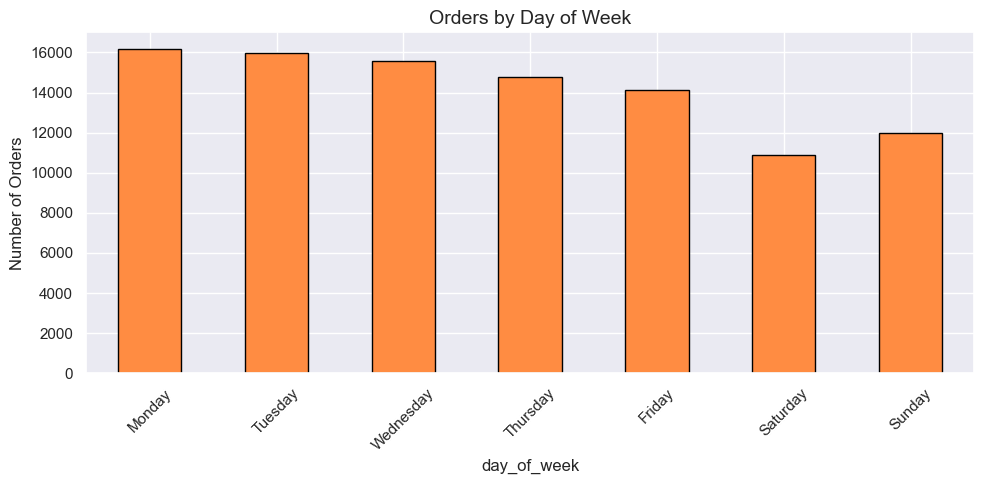

Observation:
- Weekdays have significantly more orders than weekends
- Monday and Tuesday are peak ordering days
- Sunday has the least orders — typical for B2C e-commerce in Brazil


In [33]:
# Day of week analysis
orders['day_of_week'] = orders['order_purchase_timestamp'].dt.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

fig, ax = plt.subplots(figsize=(10, 5))
orders['day_of_week'].value_counts().reindex(day_order).plot(kind='bar', color='#FF8C42', edgecolor='black', ax=ax)
ax.set_title("Orders by Day of Week", fontsize=14)
ax.set_ylabel("Number of Orders")
ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

print("Observation:")
print("- Weekdays have significantly more orders than weekends")
print("- Monday and Tuesday are peak ordering days")
print("- Sunday has the least orders — typical for B2C e-commerce in Brazil")

## 8. Geolocation & Seller Analysis

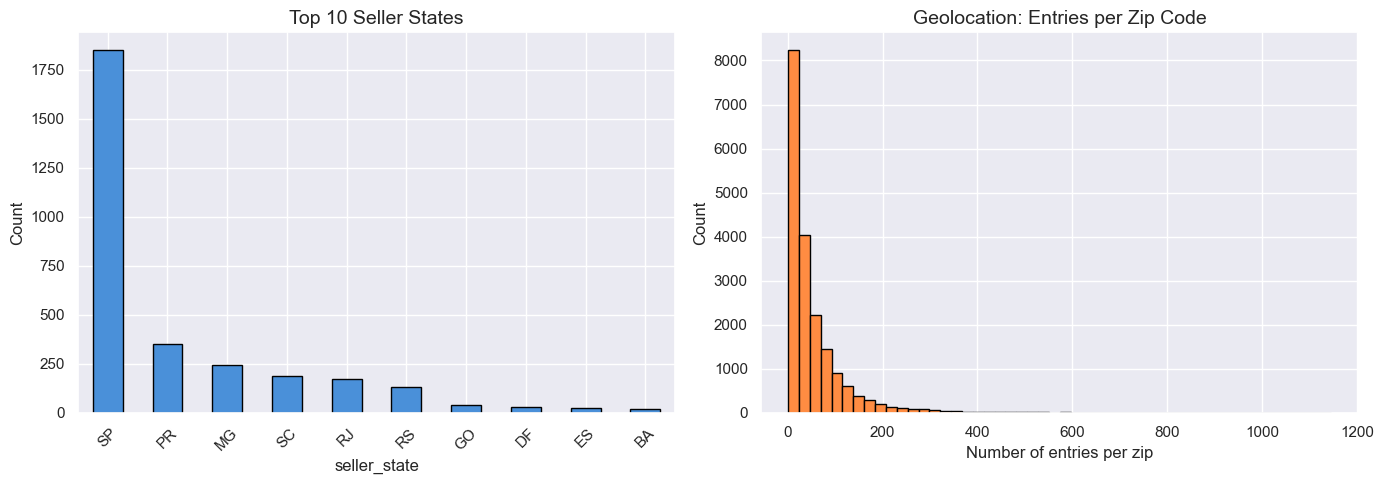

Observation:
- SP has most sellers — matches customer concentration
- Total unique sellers: 3,095
- Geolocation has 1,000,163 rows but only 19,015 unique zip codes
- Geolocation needs heavy deduplication — ~50x duplicate entries per zip on average


In [34]:
# Seller distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sellers['seller_state'].value_counts().head(10).plot(kind='bar', ax=axes[0], color='#4A90D9', edgecolor='black')
axes[0].set_title("Top 10 Seller States", fontsize=14)
axes[0].set_ylabel("Count")
axes[0].tick_params(axis='x', rotation=45)

# Geolocation duplicates check
geo_dupes = geo.groupby('geolocation_zip_code_prefix').size()
axes[1].hist(geo_dupes.values, bins=50, color='#FF8C42', edgecolor='black')
axes[1].set_title("Geolocation: Entries per Zip Code", fontsize=14)
axes[1].set_xlabel("Number of entries per zip")
axes[1].set_ylabel("Count")

plt.tight_layout()
plt.show()

print("Observation:")
print(f"- {sellers['seller_state'].value_counts().head(1).index[0]} has most sellers — matches customer concentration")
print(f"- Total unique sellers: {sellers['seller_id'].nunique():,}")
print(f"- Geolocation has {geo.shape[0]:,} rows but only {geo['geolocation_zip_code_prefix'].nunique():,} unique zip codes")
print("- Geolocation needs heavy deduplication — ~50x duplicate entries per zip on average")

## 9. Key Observations & Cleaning Decisions

Based on the EDA above, here are the key findings and what needs to be done during data cleaning:

### Key Findings:
1. **96.5% orders are delivered** — very healthy fulfillment rate
2. **Sao Paulo dominates** — ~42% customers and most sellers are from SP
3. **Credit card is #1 payment method** (~74%)
4. **Review scores skewed towards 5 stars** — but 1-star reviewers have higher avg spend
5. **Late delivery is the #1 driver of bad reviews** — strongest correlation in the data
6. **Business was growing** from 2017 to mid-2018 (Nov 2017 Black Friday spike visible)
7. **Weekdays see more orders** than weekends (Monday/Tuesday peak)
8. **Price distribution is right-skewed** — most products under 200 BRL, but outliers up to 6,735 BRL
9. **Home/furniture categories dominate** the product catalog

### Cleaning Actions Needed:
| Issue | Action |
|---|---|
| Date columns stored as strings | Convert to datetime |
| Product categories in Portuguese | Merge translation table, convert to English |
| 610 products missing category + dimensions | Fill category with "other", dimensions with median |
| 87K+ review titles and 58K+ messages missing | Fill with empty string |
| Geolocation has 1M rows with massive duplicates | Deduplicate — keep 1 per zip code |
| City names have inconsistent casing | Standardize to Title Case |
| Delivery dates missing for undelivered orders | Fill with "Not Delivered" or 0 |
| Payments have multiple rows per order | Aggregate to 1 row per order |

### Feature Engineering Needed:
| Feature | Purpose |
|---|---|
| delivery_delay_days | Actual - Estimated delivery date |
| is_late flag | 1 if delivered after estimate |
| total_price | price + freight_value |
| RFM scores | Customer segmentation |
| Churn flag | 90+ days since last order |
| order_year, order_month, day_of_week | Time-based analysis |